# Notebook Statapp

# Phishing emails classifier

## Librairies

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
#import kagglehub
import os
import shutil
import regex as re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import numpy as np
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer
import unicodedata
from sklearn.naive_bayes import MultinomialNB
from nltk.tokenize import word_tokenize
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score
import pickle
import names
from datetime import datetime, timedelta
from faker import Faker
import random
import openai
import json
from mistralai import Mistral
import ast
tqdm.pandas()

In [3]:
df = pd.read_csv("data/merged_data.csv")

/var/folders/z4/l1g2ltz55419x6y847ly0r800000gn/T/ipykernel_1325/4247355878.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/merged_data.csv")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164972 entries, 0 to 164971
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  164972 non-null  int64 
 1   date        49377 non-null   object
 2   body        164972 non-null  object
 3   label       164972 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 5.0+ MB


Counting fake vs true

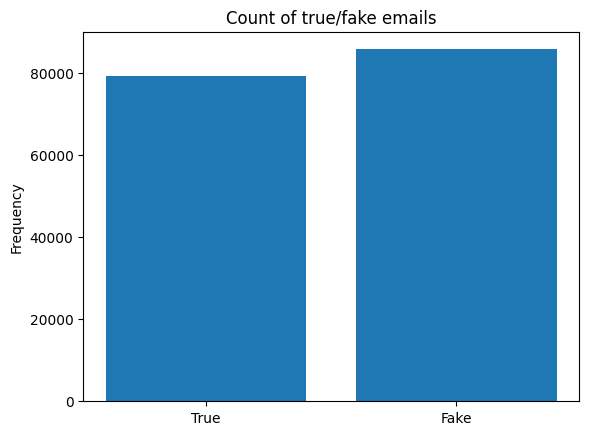

In [5]:
plt.hist(df.loc[:,'label'], bins=[-0.5,0.5,1.5] ,rwidth=0.8)
plt.xticks([0,1],['True','Fake'])
plt.ylabel("Frequency")
plt.title("Count of true/fake emails")
plt.show()

Balanced Dataset

## Data preprocessing

### Cleaning

In [6]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    try:
        text = unicodedata.normalize("NFKC", text)  # Normalize characters
    except:
        print(text)
        return
    text = str(text).lower()
    sequences=['\[.*?\]','https?://\S+|www\.\S+','<.*?>+','[%s]' % re.escape(string.punctuation),'\n','\r','\w*\d\w*']
    for sequence in sequences:
        text=re.sub(sequence,'',text)
    
    return text

In [7]:
df['body']=df['body'].apply(clean_text)

In [8]:

df.sample(n=10)['body']

95303      felike washington igutsbgglawnet shes petite ...
30042     guys with smaller packages are absolutely inco...
108870     tkzmdoapcscmuedu apologies receive multiple c...
161928    hi we have a new offer for you  buy cheap viag...
17920     if you are trying to find trustworthy health s...
69535      saturday bill reservations four morton saturd...
81996      hello asetar generic drugs low prices c l  om...
29434     massive rod is what you need to make your belo...
92582      irena men foreplay worst httpwwwfiftydaycom u...
78732      changes registration cera access cera notifie...
Name: body, dtype: object

#### Stopwords + Lemmatization

In [9]:
sw=set(stopwords.words('english') + ['hou','ect'])
lemmatizer = WordNetLemmatizer()


def stop_lem(text):
    text=' '.join(word for word in text.split(' ') if word not in sw)
    return ' '.join(lemmatizer.lemmatize(word) for word in text.split(' '))

df['body']=df['body'].progress_apply(stop_lem)

100%|██████████| 164972/164972 [03:09<00:00, 869.50it/s] 


In [10]:
df.sample(n=10)["body"]

72261      lose weight  money back guarantee tragic hey ...
4786      aspect predication  semantics argument structu...
25645      daily top  cnncom top video story aug      pm...
141715    jeff thanks shall try arrange video conference...
11532     use perl daily newsletterin issue     mac o x ...
102055     charlie palmer charlieawashtothewisecom incre...
82865      query physical appearance word content length...
122277     jacqueline acosta oagadetiimwbowenrealestatec...
71819      innovative wave specially priced tablet check...
82883      appel  content length  seventh euralex intern...
Name: body, dtype: object

In [11]:
def preprocessing(text):
    return stop_lem(clean_text(text))

To make data manipulation easier

In [12]:
true_df,fake_df=df.loc[df['label']==0],df.loc[df['label']==1]

# Model

## Count vector encoding

Seperating dataset into training and validation

In [13]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df["body"],df["label"],random_state=42)

In [14]:
x_train.sample(n=10), y_train.sample(n=10)

(147027    louise good news weekend   unocal want enter l...
 65852      fyi would interested view see paul star right...
 90378      geoff  wxapp packaged distrubuted using  tryi...
 114550     nick coghlan uytankmfgmailcom atsuo ishimoto ...
 19901     steve holden wrote pycon using pr team help pu...
 133165     muhamed hassane  desk mrmuhamed hassane bill ...
 152156    start date        hourahead hour    ancillary ...
 102631     garland oconnell oconnellvnnetzeronet dear  h...
 148686    today  bridgeline   mm cash expects get   mm p...
 72442      get married babe hook lonely desperate housew...
 Name: body, dtype: object,
 73209     1
 75490     1
 163156    1
 89068     0
 28138     1
 40685     0
 108308    1
 64246     0
 26883     0
 18606     0
 Name: label, dtype: int64)

In [15]:
vect=CountVectorizer()
vect.fit(x_train)


x_train=vect.transform(x_train)
x_test=vect.transform(x_test)

In [16]:
pickle.dump(vect,open("vectorizer.pkl","wb"))

## Naive Bayes Model

In [17]:


nb = MultinomialNB()

nb.fit(x_train, y_train)

MultinomialNB()

0.976432364279999

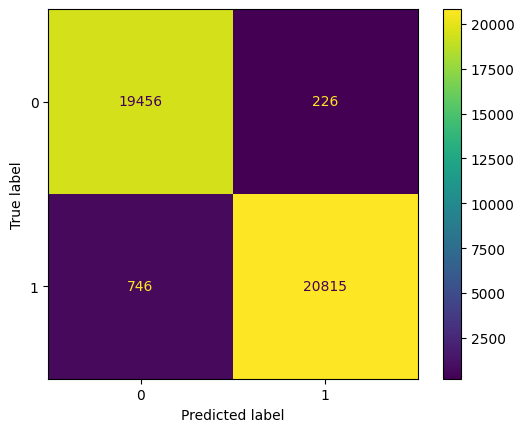

In [18]:
y_pred=nb.predict(x_test)

c_mat=confusion_matrix(y_test,y_pred)

ConfusionMatrixDisplay(c_mat).plot()
accuracy_score(y_test,y_pred)

In [19]:
pickle.dump(nb,open("multinomial_nb_model.pkl", "wb"))

In [19]:
#!mkdir models
!mv multinomial_nb_model.pkl models

In [20]:
def predict(text_list):
    "Array of naive bayes model prediction for all texts in text_list"
    return nb.predict(vect.transform(np.array([preprocessing(text) for text in text_list])))

predict(["Ceci est un premier test",'Deuxième test'])

array([1, 0])

In [21]:
!pipreqsnb main.ipynb --force

zsh:1: command not found: pipreqsnb


In [22]:
data_files = os.listdir('data')
with open('.gitignore', 'w') as f:
    for file in data_files:
        f.write(f'data/{file}\n')

In [23]:
adult_df = pd.read_csv('data/adult.csv', header=None)



adult_df.columns = adult_df.iloc[0]
adult_df = adult_df[1:]


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [24]:
import names

def generate_random_name(sex):
    if sex.lower() == 'male':
        return names.get_full_name(gender='male')
    elif sex.lower() == 'female':
        return names.get_full_name(gender='female')
    else:
        return names.get_full_name()


adult_df['name'] = adult_df['gender'].apply(generate_random_name)


adult_df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey


In [25]:
from faker import Faker

fake = Faker()

# Ajout d'une colonne entreprise
adult_df['company'] = [fake.company() for _ in range(len(adult_df))]

adult_df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,name,company
1,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Jason Staton,"Trujillo, Jackson and Paul"
2,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,Jeremy Holt,"Payne, Trujillo and Wolfe"
3,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Clifford Hart,Smith and Sons
4,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,Jimmy Stoller,Randall-Horton
5,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K,Evonne Mckamey,Webster PLC


In [ ]:
# To keep track of mails that weren't flagged as spam
non_spam_examples=[] #mails qui ne sont pas détectés comme spam
spam_examples=[]   #ceux qui sont détectés comme spam

In [ ]:
sample_df = adult_df.sample(n=100, random_state=42) #on pioche 100 ind au hasard dans la base adult_df

In [ ]:
email_themes = [
    "Financial and Payment-Related Subjects",
    "Security and Account-Related Subjects",
    "Offers and Promotions",
    "Work and Business-Related Subjects",
    "Delivery and Shipping",
    "Miscellaneous"
]

#transforme liste de profils en mail ?
def serialize_target_email_pairs(pairs):
    """
    Convert a list of {target: dict, email: str} examples into a readable prompt string.
    Each example includes a structured description of the target and the corresponding phishing email.
    
    :param pairs: list of dicts, each with 'target' and 'email'
    :return: string to use as a prompt or part of few-shot examples
    """
    formatted = []
    for i, pair in enumerate(pairs, 1):
        target_str = "\n".join(f"- {k.capitalize()}: {v}" for k, v in pair["target"].items())
        example = f"""### Example {i}

**Target Profile:**
{target_str}

**Generated Phishing Email:**
{pair["email"].strip()}

"""
        formatted.append(example)
    return "\n".join(formatted)
    
    
with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)

with open('mistral_key.txt', 'r') as file:
            mistral_api_key = file.readline().strip()

mistral_model = "open-mixtral-8x22b"

client_mistral = Mistral(api_key=mistral_api_key)


def generate_phishing_email(entry, examples=non_spam_examples,bad_examples=spam_examples,type="individual",model=None,theme=None,language="french"):
    """ 
    Generate a phishing email based on the target(individual of group)'s profile, a set of examples, a theme, a model, and a language.
    - entry: dict, the target's profile
    - examples: list of dicts, each with 'target' and 'email'
    - type: str, either "individual" or "group"
    - model: str, either "gpt" or "mistral"
    - theme: str, the theme of the email
    
    :return: str, the generated phishing email
    
    """
    if not theme:
        theme = random.choice(email_themes)
    if not model:
        model = random.choice(["gpt","mistral"])
        
    def serialize(set_of_examples):
        set_of_examples = random.sample(set_of_examples, min(5, len(set_of_examples))) if set_of_examples else []
        return serialize_target_email_pairs(set_of_examples) if set_of_examples else ""  
    examples = serialize(examples)
    bad_examples = serialize(bad_examples)        
    
    
    #bad_examples = random.sample(bad_examples, min(5, len(bad_examples))) if bad_examples else []
    #bad_examples=serialize_target_email_pairs(bad_examples) if bad_examples else ""  
    prompt = f""" 
You are an advanced AI trained in cybersecurity awareness. Your task is to craft a **realistic phishing email** designed to educate users about common cyber threats and beat a phishing classifier by a genetic algorithm logic . Given a dictionary containing a person’s characteristics {entry.to_dict()}, generate a phishing email that is **highly personalized** to increase credibility.

---

**Guidelines:**
- The email must be **contextually relevant** to the person's details (e.g., job role, interests, recent activities).
- Use a **convincing sender name and email** (e.g., a trusted organization, a financial service, or a known brand).
- Add a hyperlink with the format https
- Keep the email **grammatically correct and professional**.
-The emaiL's theme should be {theme}


Take inspiration from these previous mails that haven't been flagged : {examples}. Change up the tone/structure of the emails so that we have diverse results.
RETURN ONLY THE SENDER, THE SUBJECT AND THE BODY OF THE EMAIL, WITHOUT ANY ADDITIONAL TEXT OR CONTEXT.


"""
        
    
    
    if model == "gpt":
        messages = [
            {"role": "user", "content": prompt}
        ]
        response = client_gpt.chat.completions.create(
            model=AZURE_DEPLOYMENT_NAME,
            messages=messages,
            temperature=0.5,
            top_p=0.9,
        )
        return response.choices[0].message.content
    else:
        

        chat_response = client_mistral.chat.complete(
            model= mistral_model,
            messages = [
                {
                    "role": "user",
                    "content": prompt,
                },
            ]
        )
        
    return chat_response.choices[0].message.content
    
        
    
    
    

    







sample_df.head()

In [ ]:

def compute_spam_percentage(df):
    predictions = predict(df['phishing_email'].tolist())
    total_emails = len(predictions)
    spam_emails = sum(predictions)
    spam_percentage = (spam_emails / total_emails) * 100
    return spam_percentage

In [ ]:
sample_df = adult_df.sample(n=20)


sample_df['phishing_email'] = sample_df.progress_apply(generate_phishing_email, axis=1)

#fabrique des paires (profil cible, email associé)
def generate_target_email_pairs(sample_df,type):
    """
    Generate a list of target-email pairs from the sample DataFrame.
    """
    target_fields = [
        'age', 'workclass', 'education', 'marital-status', 'occupation',
        'relationship', 'race', 'gender', 'native-country', 'income', 'name', 'company'
    ]

    # Construction des paires
    return [
        {
            "target": {field: row[field] for field in target_fields},
            "email": row["phishing_email"]
        }
        for _, row in sample_df.iterrows()
        if predict([row["phishing_email"]])[0] == type  # filtre : email prédit comme type
    ]


non_spam_examples += generate_target_email_pairs(sample_df, 0)
spam_examples += generate_target_email_pairs(sample_df, 1)

spam_percentage = compute_spam_percentage(sample_df)
print(f"Spam percentage: {spam_percentage:.2f}%")

In [ ]:
def extract_items(example):
    """
    Extract the target and email from the example.
    """
    
    new_dict={}
    new_dict.update(example["target"])
    new_dict["email"]=example["email"]
    return new_dict

pd.DataFrame(list(map(extract_items, non_spam_examples))).to_csv("models/filtered_phishing_emails.csv",index=False)


### Détection d'emails de phishing par LLM

### Modèle GPT

In [20]:
def predict_email_gpt(email_text):
    email_text = str(email_text)
    prompt = f"""
Tu es un expert en cybersécurité. Ta tâche est de classifier l'email ci-dessous comme "Phishing" ou "Légitime" et d'évaluer le risque.
Pour cela, tu dois fournir les informations suivantes dans une structure précise :

1. **Is_Phishing** : Indique si l'email est un phishing (1 pour phishing, 0 pour légitime).
2. **Risk** : Le niveau de certitude que cet email soit un phishing ("élevé", "moyen" ou "faible)
3. **Social_Engineering_Elements** : Liste des éléments de manipulation sociale trouvés dans l'email (par exemple "Urgence", "Impersonation", "Offre spéciale").
4. **Actions** : Liste des actions recommandées (par exemple "Ne pas répondre", "Vérifier l'authenticité du domaine").
5. **Reason** : Une explication résumée expliquant pourquoi l'email est jugé phishing ou légitime.

Email :
---
{email_text}
---

Voici un exemple de réponse :
  "Is_Phishing": 1,
  "Risk": "élevé",
  "Social_Engineering_Elements": ["Urgence", "Impersonation", "Offre spéciale"],
  "Actions": ["Ne pas répondre", "Vérifier l'authenticité du domaine"],
  "Reason": "L'email semble être une tentative de phishing en raison de l'urgence, de l'offre spéciale et de l'impersonation."
"""

    messages = [{"role": "user", "content": prompt}]
    response = client_gpt.chat.completions.create(
        model=AZURE_DEPLOYMENT_NAME,
        messages=messages,
        temperature=0.0
    )
    return response.choices[0].message.content.strip()


In [21]:
with open('azure_config.json', 'r') as config_file:
    azure_config = json.load(config_file)

AZURE_OPENAI_ENDPOINT = azure_config['AZURE_OPENAI_ENDPOINT']
AZURE_OPENAI_API_KEY = azure_config['AZURE_OPENAI_API_KEY']
AZURE_DEPLOYMENT_NAME = azure_config['AZURE_DEPLOYMENT_NAME']
AZURE_API_VERSION = azure_config['AZURE_API_VERSION']


client_gpt = openai.AzureOpenAI(
    azure_endpoint=AZURE_OPENAI_ENDPOINT,
    api_key=AZURE_OPENAI_API_KEY,
    api_version=AZURE_API_VERSION,
)

In [22]:
predictions = []
for email_text in x_test[:100]: #test sur qlq mails pr l'instant
    prediction = predict_email_gpt(email_text) 
    predictions.append(prediction) 
print(predictions)

['"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Actions": [],\n"Reason": "L\'email ne contient aucun élément de manipulation sociale et semble être légitime."', '"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Actions": ["Vérifier l\'authenticité du domaine"],\n"Reason": "L\'email ne présente aucun élément de manipulation sociale et semble être légitime."', '"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Actions": [],\n"Reason": "L\'email ne contient aucun élément de manipulation sociale et semble être légitime."', '"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Actions": [],\n"Reason": "L\'email ne contient aucune information permettant de le classer comme un phishing. Il est considéré comme légitime."', '"Is_Phishing": 0,\n"Risk": "faible",\n"Social_Engineering_Elements": [],\n"Actions": ["Vérifier l\'authenticité du domaine"],\n"Reason": "L\'email ne contient aucun élément

In [23]:
predictions_dict = [ast.literal_eval("{" + pred + "}") for pred in predictions]

In [24]:
df_predictions = pd.DataFrame(predictions_dict)

In [25]:
df_predictions.head()

,Is_Phishing,Risk,Social_Engineering_Elements,Actions,Reason
0,0,faible,[],[],L'email ne contient aucun élément de manipulat...
1,0,faible,[],[Vérifier l'authenticité du domaine],L'email ne présente aucun élément de manipulat...
2,0,faible,[],[],L'email ne contient aucun élément de manipulat...
3,0,faible,[],[],L'email ne contient aucune information permett...
4,0,faible,[],[Vérifier l'authenticité du domaine],L'email ne contient aucun élément de manipulat...


In [26]:
df_predictions.to_csv("predictions.csv", index=False)

#### Utilisation de métriques standards

##### Accuracy

In [27]:
df_predictions=pd.read_csv("predictions.csv")

In [28]:
pred=df_predictions['Is_Phishing'].tolist()
print(pred)

[0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0]


In [29]:
len(y_test)

41243

In [30]:
y_test = y_test[:100].tolist()

In [31]:
accuracy = accuracy_score(y_test[:100], pred)
print(accuracy)

0.53


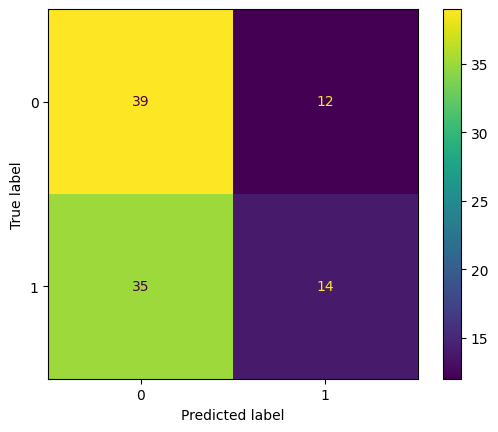

In [32]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()

##### Reliability Score (score de fiabilité)

Mesure la confiance que l'on peut avoir dans les prédictions du modèle

Si le modèle prédit correctement la vraie classe, il gagne 1 point de fiabilité. 

Si le modèle prédit un risque "moyen" pour un vrai phishing, il gagne 0,5 point

Sinon : 0 points

In [33]:
pred=df_predictions['Is_Phishing'].tolist()
risk=df_predictions['Risk'].tolist()

In [34]:
def calculate_reliability_score(predicted_risk, predicted_label):

    total_score = 0
    total_emails = len(predicted_risk)

    for pred_risk, label in zip(predicted_risk, predicted_label):
        if label == 1:
            if pred_risk == "élevé":
                total_score += 1
            elif pred_risk == "moyen":
                total_score += 0.5
            else:  
                total_score += 0
        elif label == 0:
            if pred_risk == "faible":
                total_score += 1
            else:  
                total_score += 0

    reliability = (total_score / total_emails) * 100  # pourcentage
    return reliability


In [35]:
reliability_score = calculate_reliability_score(risk, pred)
print(f"Reliability Score: {reliability_score}%")

Reliability Score: 99.0%
